In [1]:
import sys,os,time 
import h5py

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 18})

from scipy.optimize import curve_fit

import KIPD_Analysis as kipd

# LED Data vs Temperature: Feb 15-16, 2023

In [2]:
datapath = "/data/USRP_Laser_TempScan_Data"

day_str    = "20230216"
V_led      = 4.0

### Define some constants

In [3]:
## PSD hi and lo frequency limits
PSD_lo_f_Hz = 1e1
PSD_hi_f_Hz = 1e6

## Fraction of timestream to trim from beginning (Transient period)
blank_fraction   = 0.1

## Quadrature for analysis
PHASE = True

## Coupling quality
Qc = 680e3

## Scaling for temperature errorbars
T_err_scale = 1.5

## Add prelim info to plot
prelim = False

### Open H5 File

In [4]:
filename = 'AvgPulsesVsTemp_'+day_str+'.h5'
filepath = os.path.join(datapath, day_str, filename)
datafile = h5py.File(filepath, 'r')

## Extract the top-level metadata
## MB Results come from fitting a temperature scan at a specified RF power
MB_fit_vals = np.array([datafile.attrs["Fr0(GHz)"] ,  ## Fr(0) [GHz]
                        datafile.attrs["D0(mev)"] ,  ## Delta [meV]
                        datafile.attrs["alpha"] ,  ## alpha
                        datafile.attrs["Qi0"] ]) ## Qi(0)

## How much attenuation is in the lines before the chip
line_atten_dB = datafile.attrs["tot_atten(dB)"]

## Get the object for the LED voltage we care about
data = datafile[f"{V_led:.1f}V"]
print("Using dataset for LED voltage:", data.attrs["voltage"], "V")

## Extract the temperature setpoints
T_sp_mK = np.sort(np.array([ float(k[:-2]) for k in data.keys() ]))
print(T_sp_mK)

datafile.close()

Using dataset for LED voltage: 4.0 V
[ 15.  25.  50.  75. 100. 125. 150. 175. 200. 225. 250. 275. 300. 325.
 350.]


In [5]:
temps_to_skip = [None] # [350.0, 100.0, 15.0] ## 20230216

### Pull the inferred RF payload temperature

In [6]:
## Open the data group for the LED voltage of interest
datafile = h5py.File(filepath, 'r')
data = datafile[f"{V_led:.1f}V"]

T_rf_mK = np.array([ data[f"{T:.1f}mK"].attrs["T_rf(mK)"] for T in T_sp_mK ])
print(T_rf_mK)

datafile.close()

[ 17.14292379  21.75686585  37.43359583  59.16880531  83.15150042
 110.53766192 146.06537611 171.3321557  186.47217594 204.18908383
 209.7893894  222.10743381 233.19467528 253.27718402 287.18869506]


### Define some pulse parameters

In [7]:
## "Trigger" time
t0 = 4.99
kipd.set_fixed_param("t0_ms",t0)
kipd.set_fixed_param("Qr", 1./( (1./MB_fit_vals[3]) + (1./Qc)  ) )
kipd.set_fixed_param("fr_Hz", MB_fit_vals[0]*1e9  )
kipd.show_fixed_params()

"t0_ms" 4.99
"Qr" 239619.0476190476
"fr_Hz" 4241980000.0


# Show the Average Pulses

RF: 17.14292378911476mK----------
RF: 21.756865845160497mK----------
RF: 37.43359582662582mK----------
RF: 59.16880530568285mK----------
RF: 83.1515004236353mK----------
RF: 110.53766191873746mK----------
RF: 146.06537610846337mK----------
RF: 171.3321557049433mK----------


/tmp/ipykernel_26278/1922235828.py:61: DeprecationWarning: `product` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `prod` instead.
  t_vals = np.array(data[f"{T_sp_mK[i]:.1f}mK/time(ms)"])
/tmp/ipykernel_26278/1922235828.py:63: DeprecationWarning: `product` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `prod` instead.
  df_vals = np.array(data[f"{T_sp_mK[i]:.1f}mK/freq"])
/tmp/ipykernel_26278/1922235828.py:64: DeprecationWarning: `product` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `prod` instead.
  dQ_vals = np.array(data[f"{T_sp_mK[i]:.1f}mK/diss"])
/tmp/ipykernel_26278/1922235828.py:65: DeprecationWarning: `product` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `prod` instead.
  k1_vals = np.array(data[f"{T_sp_mK[i]:.1f}mK/kappa1"])
/tmp/ipykernel_26278/1922235828.py:66: DeprecationWarning: `product` is deprecated as of NumPy 1.25.0, and will be remo

RF: 186.47217594048243mK----------
RF: 204.18908383325277mK----------
RF: 209.78938939573mK----------
RF: 222.1074338083186mK----------
RF: 233.1946752822639mK----------
RF: 253.27718401880244mK----------
RF: 287.1886950556832mK----------


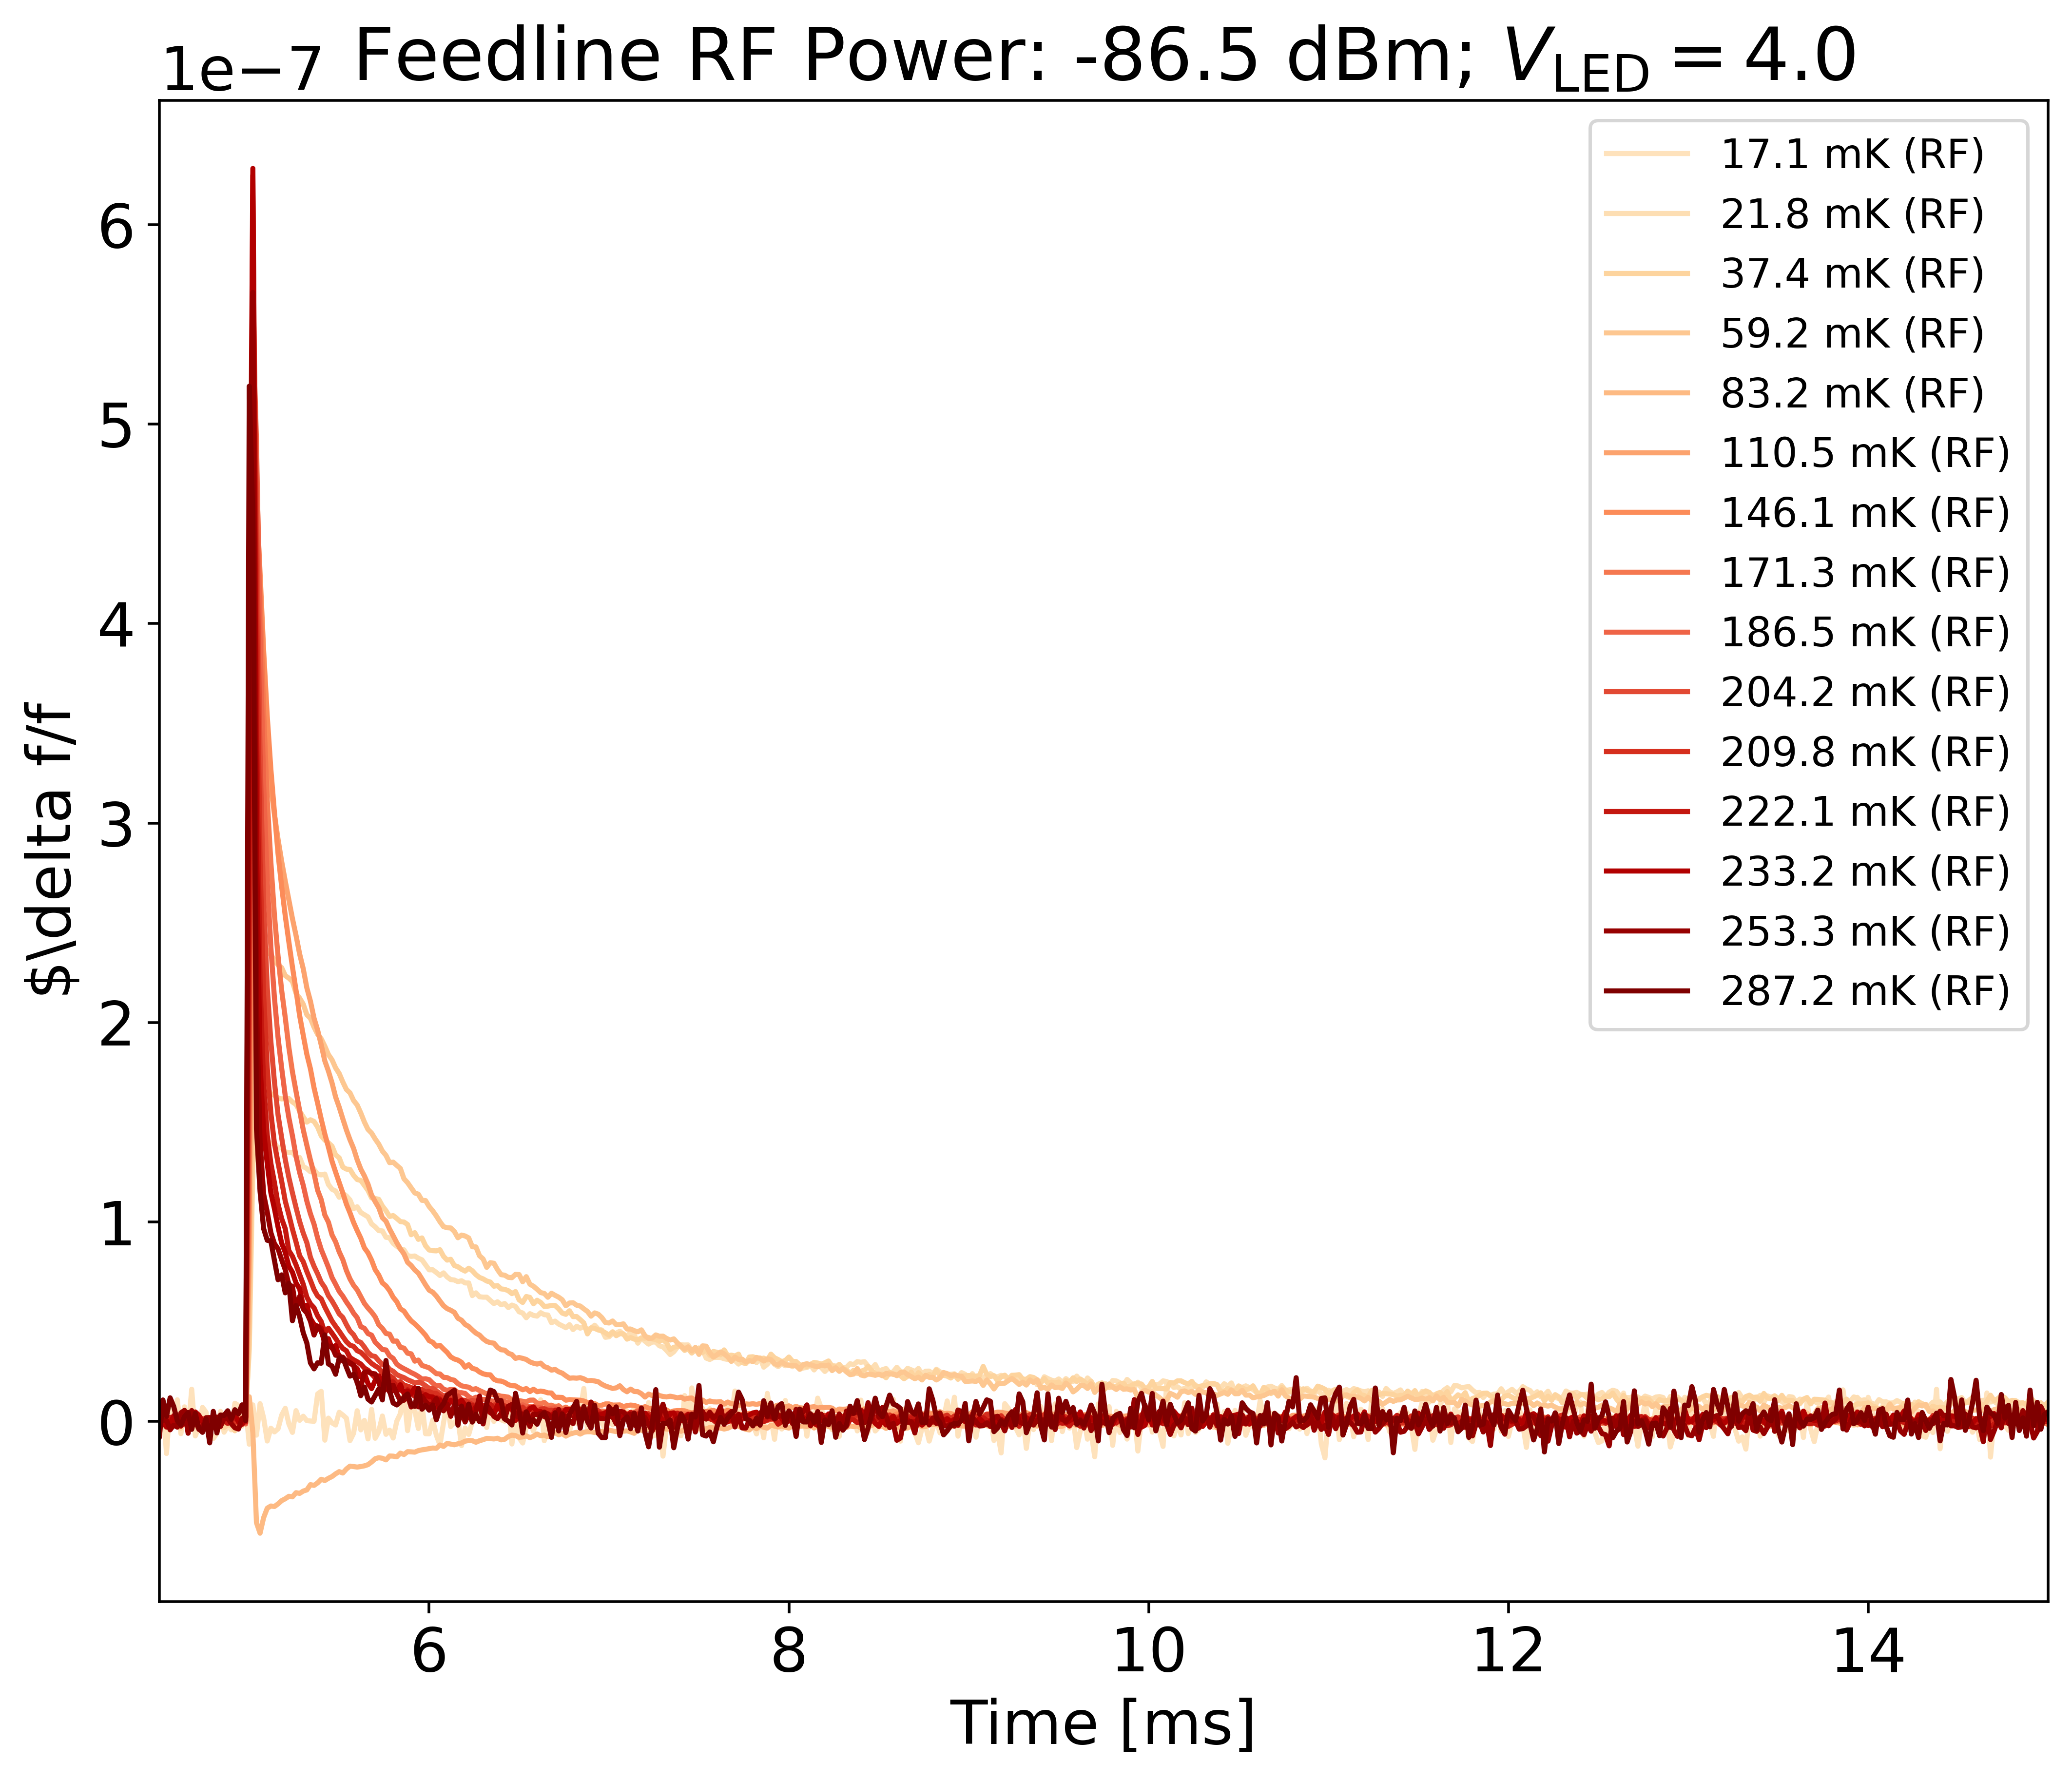

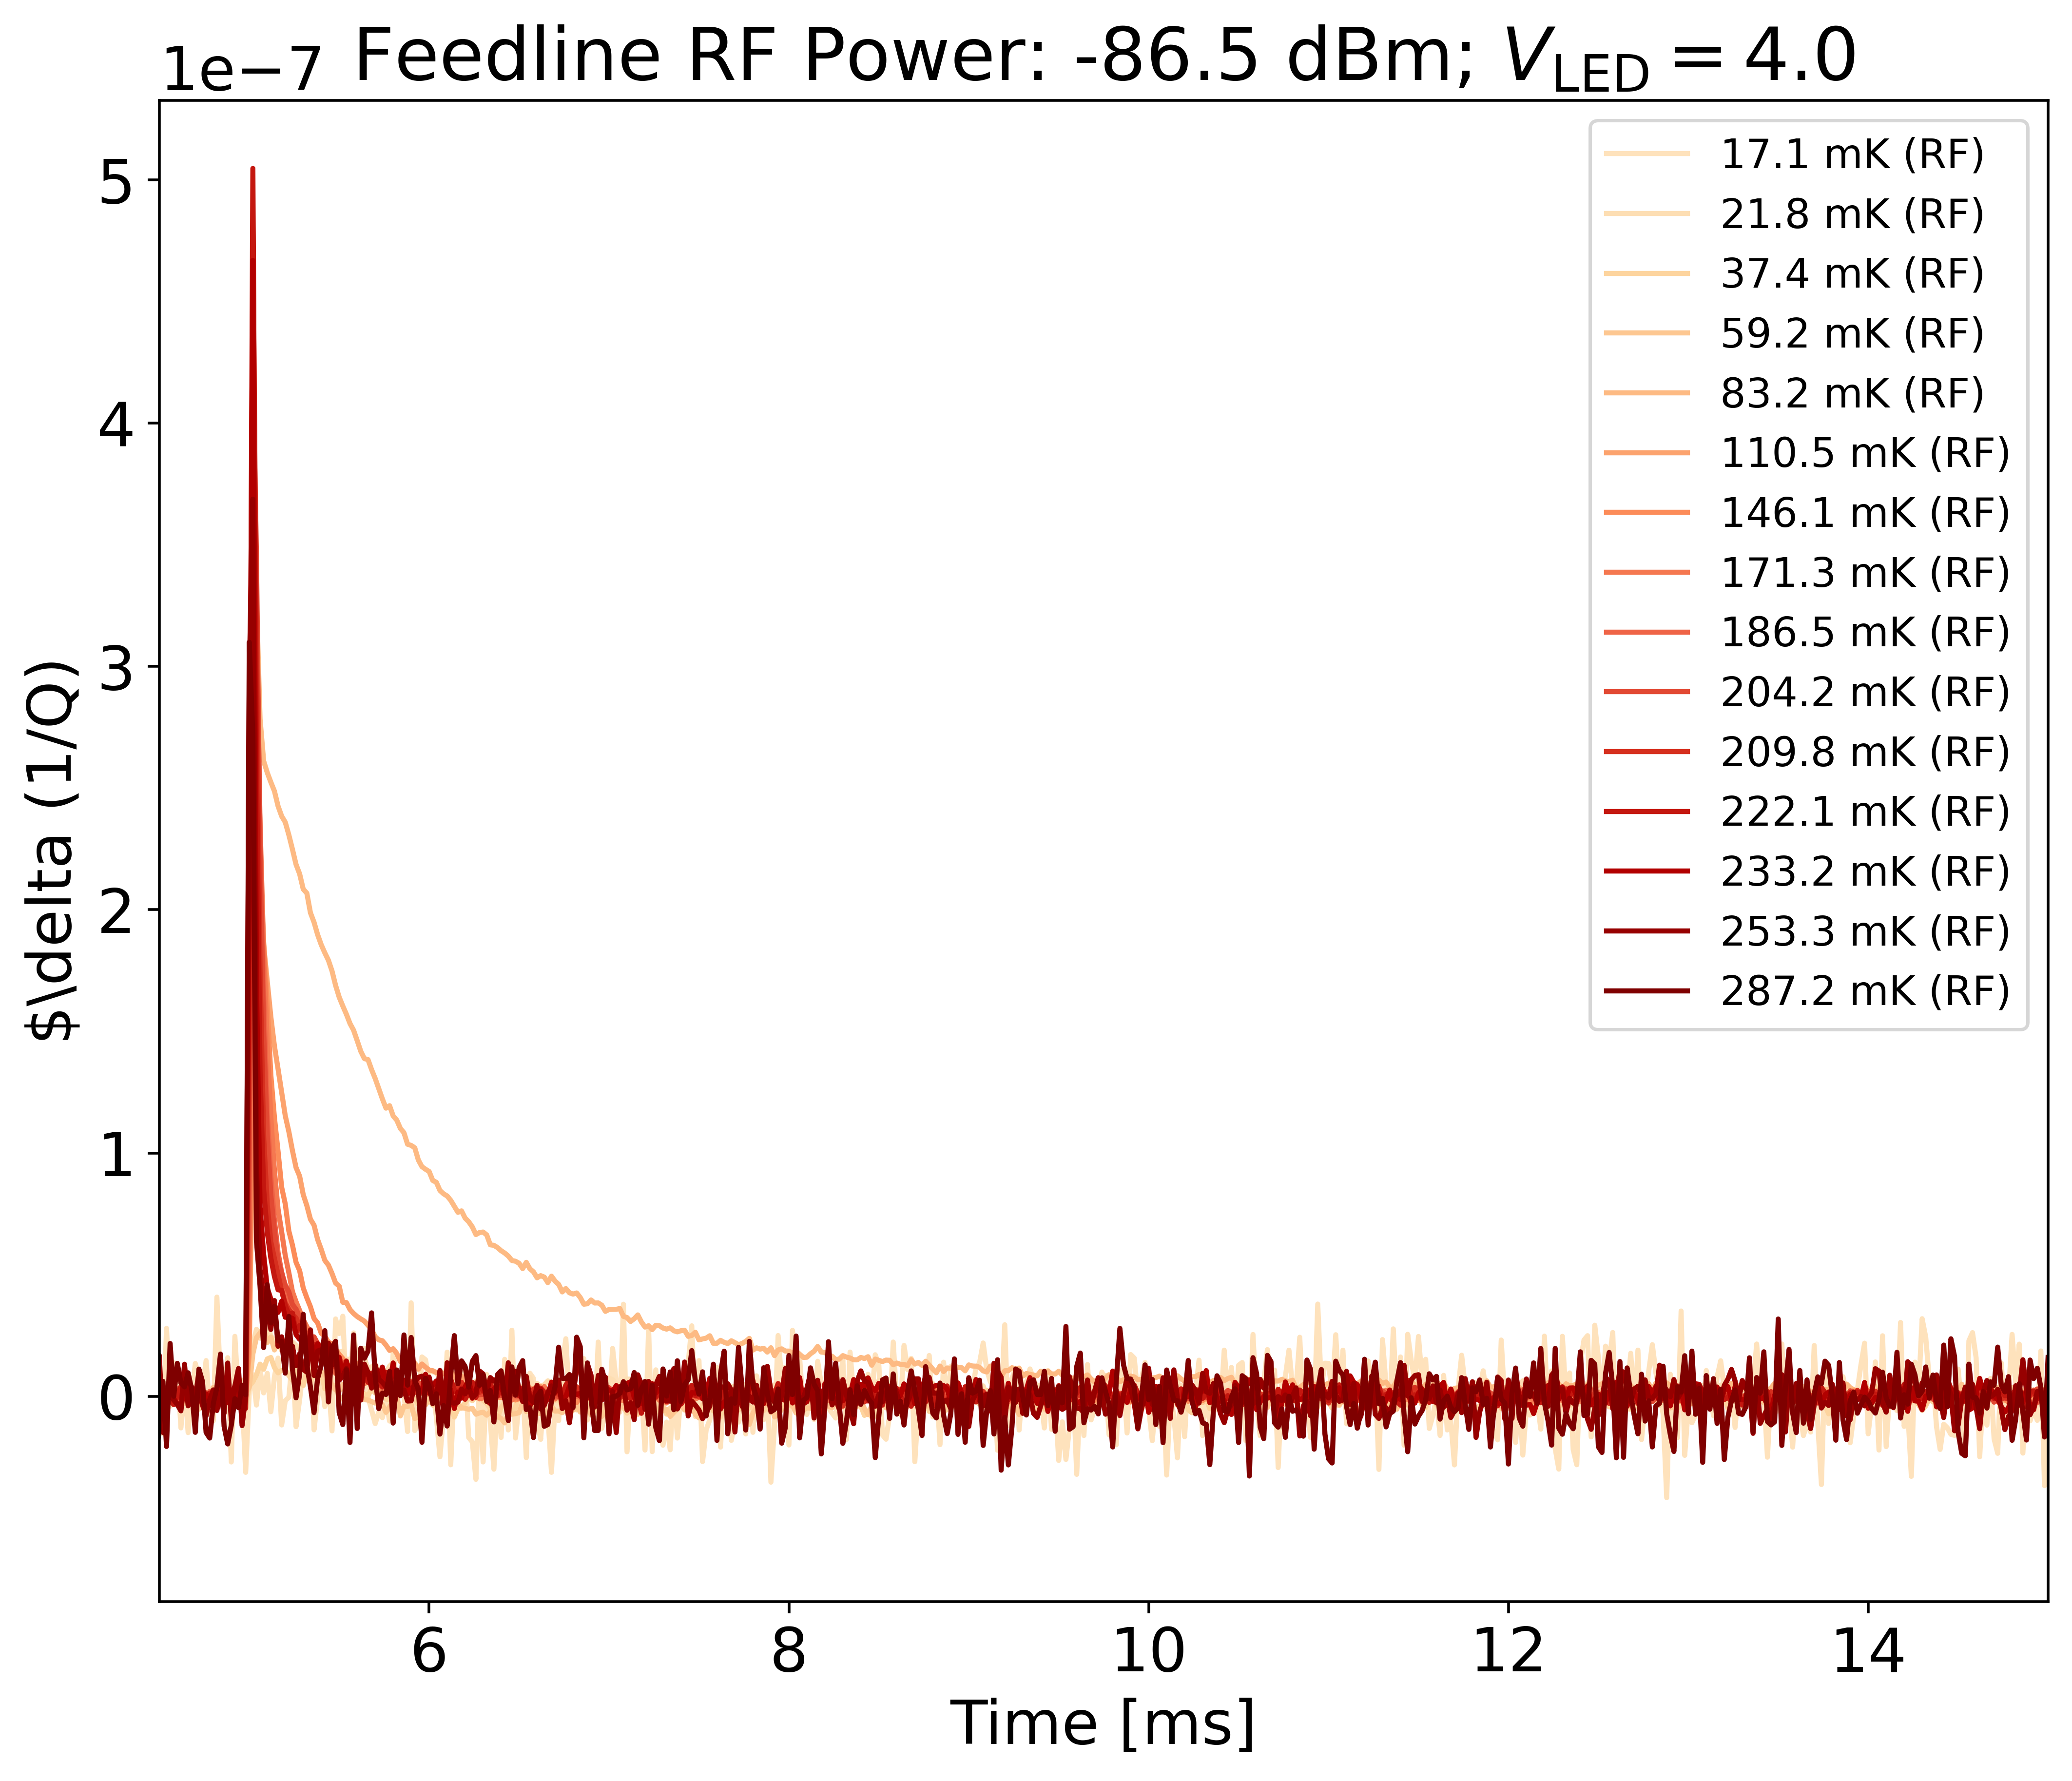

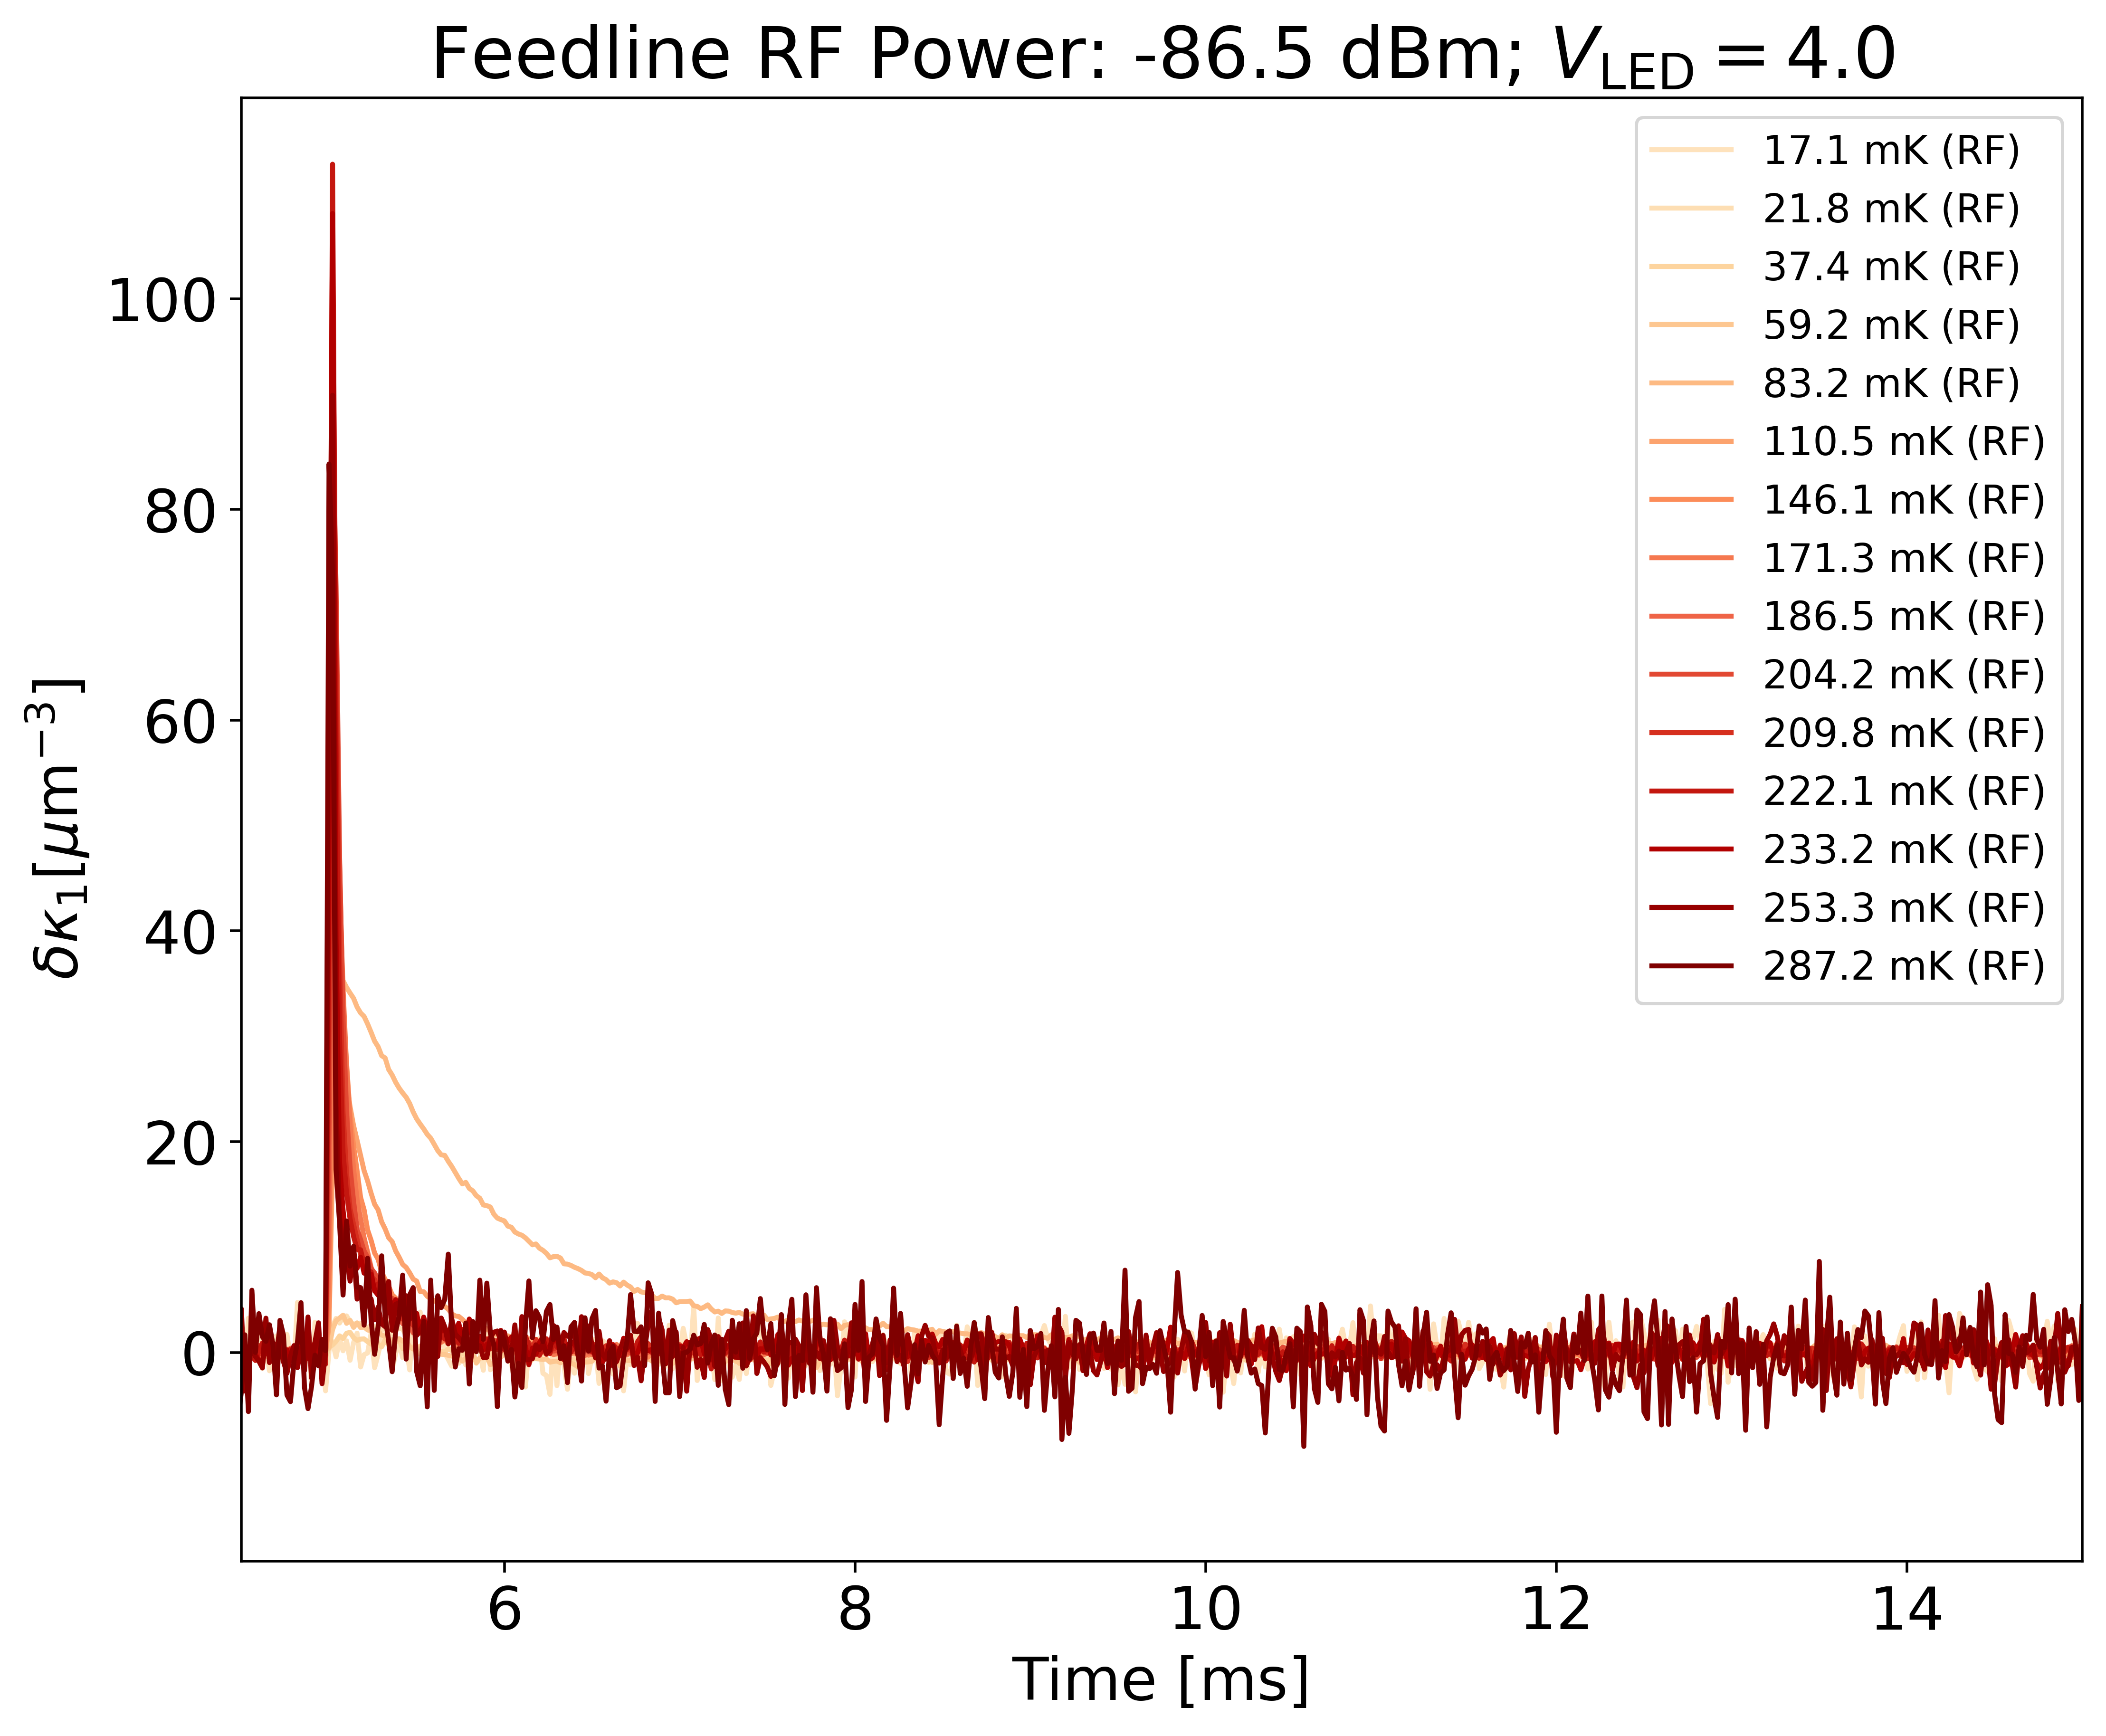

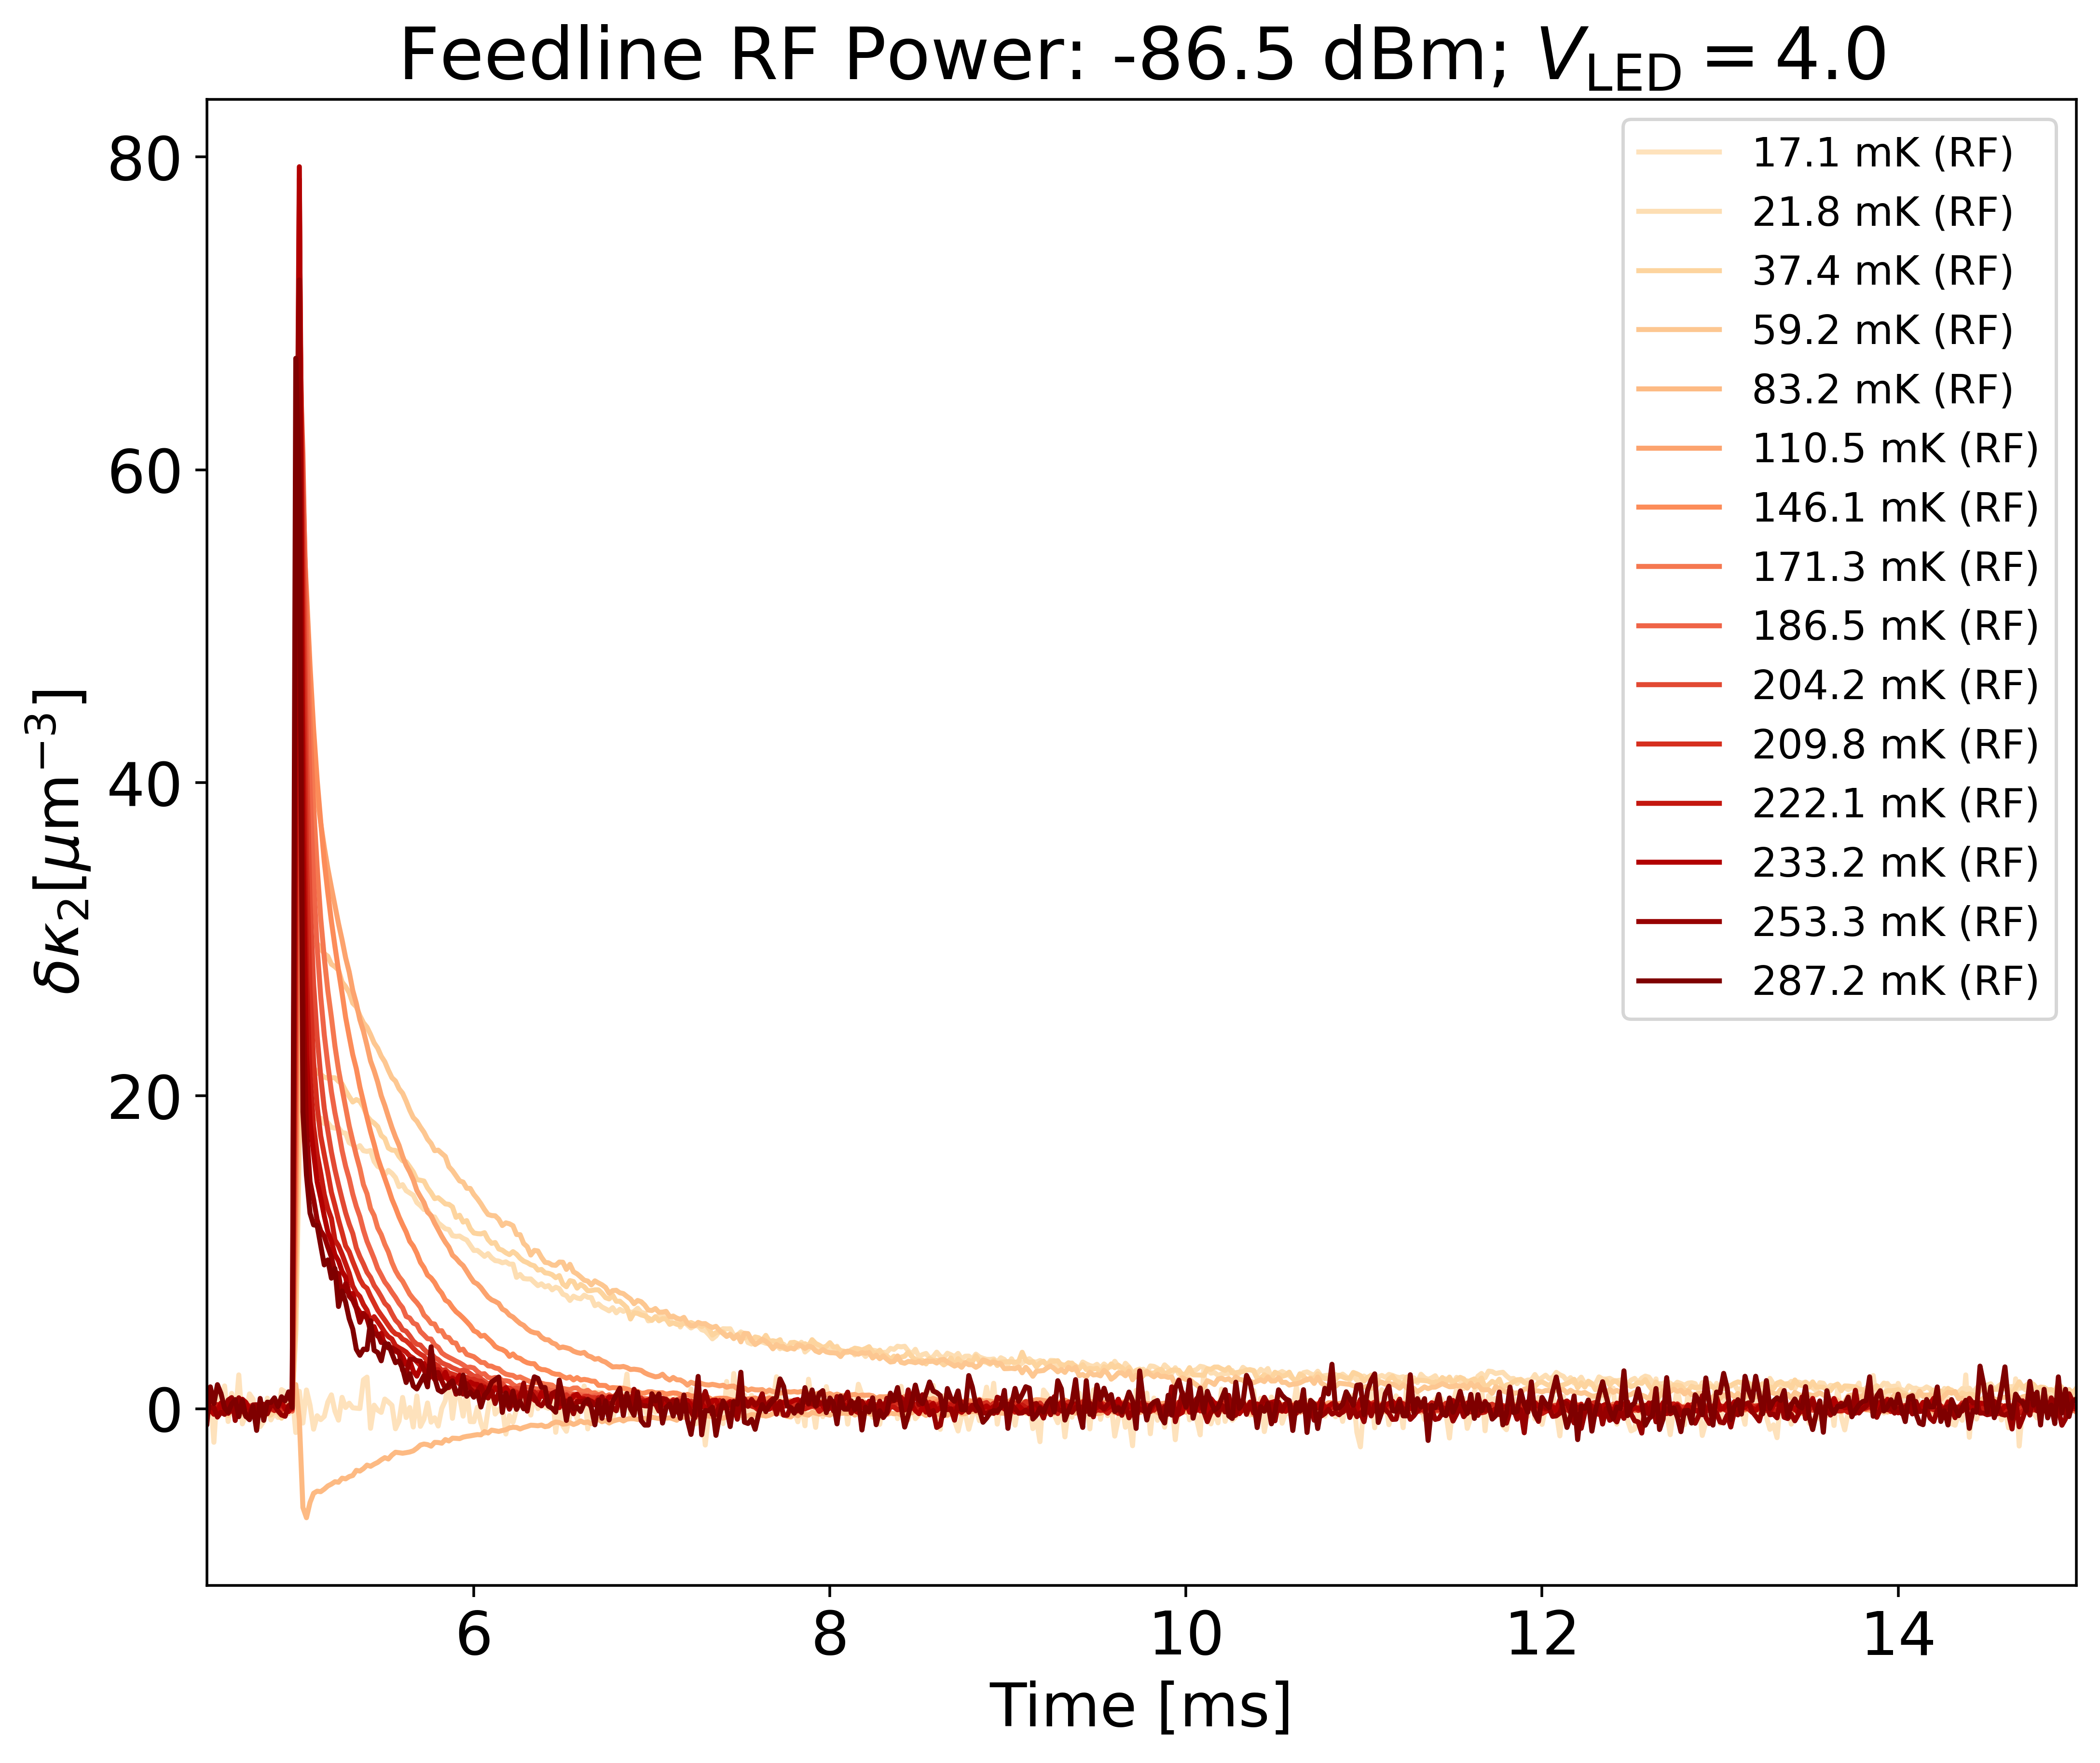

In [17]:
## Fit out to time
t_max_ms = 15.0

## Pulse plot limits
xlims    = [4.5, t_max_ms]

## Use the temperature map in the legend
show_mapped_T = True

## Scale the maxima of each peak to unity
peak_normalize = False

## Create the plots
ax0    = plt.figure("freq"  ,figsize=(10,8),dpi=500).gca()
ax00   = plt.figure("diss"  ,figsize=(10,8),dpi=500).gca()
ax000  = plt.figure("kappa1",figsize=(10,8),dpi=500).gca()
ax0000 = plt.figure("kappa2",figsize=(10,8),dpi=500).gca()

ax0.set_xlabel("Time [ms]")
ax0.set_ylabel(r"$\delta f/f")
ax0.set_title("Feedline RF Power: "+str(-30-line_atten_dB)+r" dBm; $V_\mathrm{LED}=$"+str(V_led))
ax0.set_xlim(xlims)

ax00.set_xlabel("Time [ms]")
ax00.set_ylabel(r"$\delta (1/Q)")
ax00.set_title("Feedline RF Power: "+str(-30-line_atten_dB)+r" dBm; $V_\mathrm{LED}=$"+str(V_led))
ax00.set_xlim(xlims)

ax000.set_xlabel("Time [ms]")
ax000.set_ylabel(r"$\delta \kappa_1 [\mu$m$^{-3}$]")
ax000.set_title("Feedline RF Power: "+str(-30-line_atten_dB)+r" dBm; $V_\mathrm{LED}=$"+str(V_led))
ax000.set_xlim(xlims)

ax0000.set_xlabel("Time [ms]")
ax0000.set_ylabel(r"$\delta \kappa_2 [\mu$m$^{-3}$]")
ax0000.set_title("Feedline RF Power: "+str(-30-line_atten_dB)+r" dBm; $V_\mathrm{LED}=$"+str(V_led))
ax0000.set_xlim(xlims)

## Open the data group for the LED voltage of interest
datafile = h5py.File(filepath, 'r')
data = datafile[f"{V_led:.1f}V"]
      
## Loop over each temperature and plot the average pulses
N_temps        = len(T_rf_mK)

for i in np.arange(N_temps):
    # k = data.keys()[1+i]
    print("RF: "+str(T_rf_mK[i])+ "mK----------")
    
    if T_sp_mK[i] in temps_to_skip:
        print("SKIPPING",k,"mK")
        
        i += 1
        continue
    
    ## Get the label and color for this temperature
    label = ('%.1f mK (MC)' % T_sp_mK[i]) if not show_mapped_T else ('%.1f mK (RF)' % T_rf_mK[i])
    color = kipd.get_color( T_sp_mK[i] , np.max(T_sp_mK), scale_min=0.0, offset=50.0)
    
    ## Pull the time values and average pulses
    t_vals = np.array(data[f"{T_sp_mK[i]:.1f}mK/time(ms)"])

    df_vals = np.array(data[f"{T_sp_mK[i]:.1f}mK/freq"])
    dQ_vals = np.array(data[f"{T_sp_mK[i]:.1f}mK/diss"])
    k1_vals = np.array(data[f"{T_sp_mK[i]:.1f}mK/kappa1"])
    k2_vals = np.array(data[f"{T_sp_mK[i]:.1f}mK/kappa2"])

    if peak_normalize:
        df_vals = df_vals / np.max(df_vals)
        dQ_vals = dQ_vals / np.max(dQ_vals)
        k1_vals = k1_vals / np.max(k1_vals)
        k2_vals = k2_vals / np.max(k2_vals)
    
    #### === ==================== === ###
    
    ## Add the average pulse to the to the plot of all temperatures
    ax0.plot(    t_vals, df_vals, label=label , color=color)
    ax00.plot(   t_vals, dQ_vals, label=label , color=color)
    ax000.plot(  t_vals, k1_vals, label=label , color=color)
    ax0000.plot( t_vals, k2_vals, label=label , color=color)
    
ax0.legend(fontsize='12')
ax00.legend(fontsize='12')
ax000.legend(fontsize='12')
ax0000.legend(fontsize='12')

datafile.close()

# Example Fit: Single Exponential

/tmp/ipykernel_26278/2368392706.py:18: DeprecationWarning: `product` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `prod` instead.
  t_vals = np.array(data[f"{k:.1f}mK/time(ms)"])
/tmp/ipykernel_26278/2368392706.py:19: DeprecationWarning: `product` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `prod` instead.
  p_vals = np.array(data[f"{k:.1f}mK/kappa2"])


-- Parameter guess for single exponential -- 
     Decay time constant:  0.5199999999999996 ms
     Amplitude at t=0:     690090.2071090273
[[ 7.46194765e-02 -8.30501495e-04  7.59865631e-05]
 [-8.30501495e-04  1.51471007e-05 -8.02593638e-07]
 [ 7.59865631e-05 -8.02593638e-07  2.96337572e-07]]
Amp : 49.44030900532817 +/- 0.273165657545925
Tau : 0.5641052260105215 +/- 0.0038919276331913708
Kappa : 0.01978592679725131 +/- 0.0005443689665994695


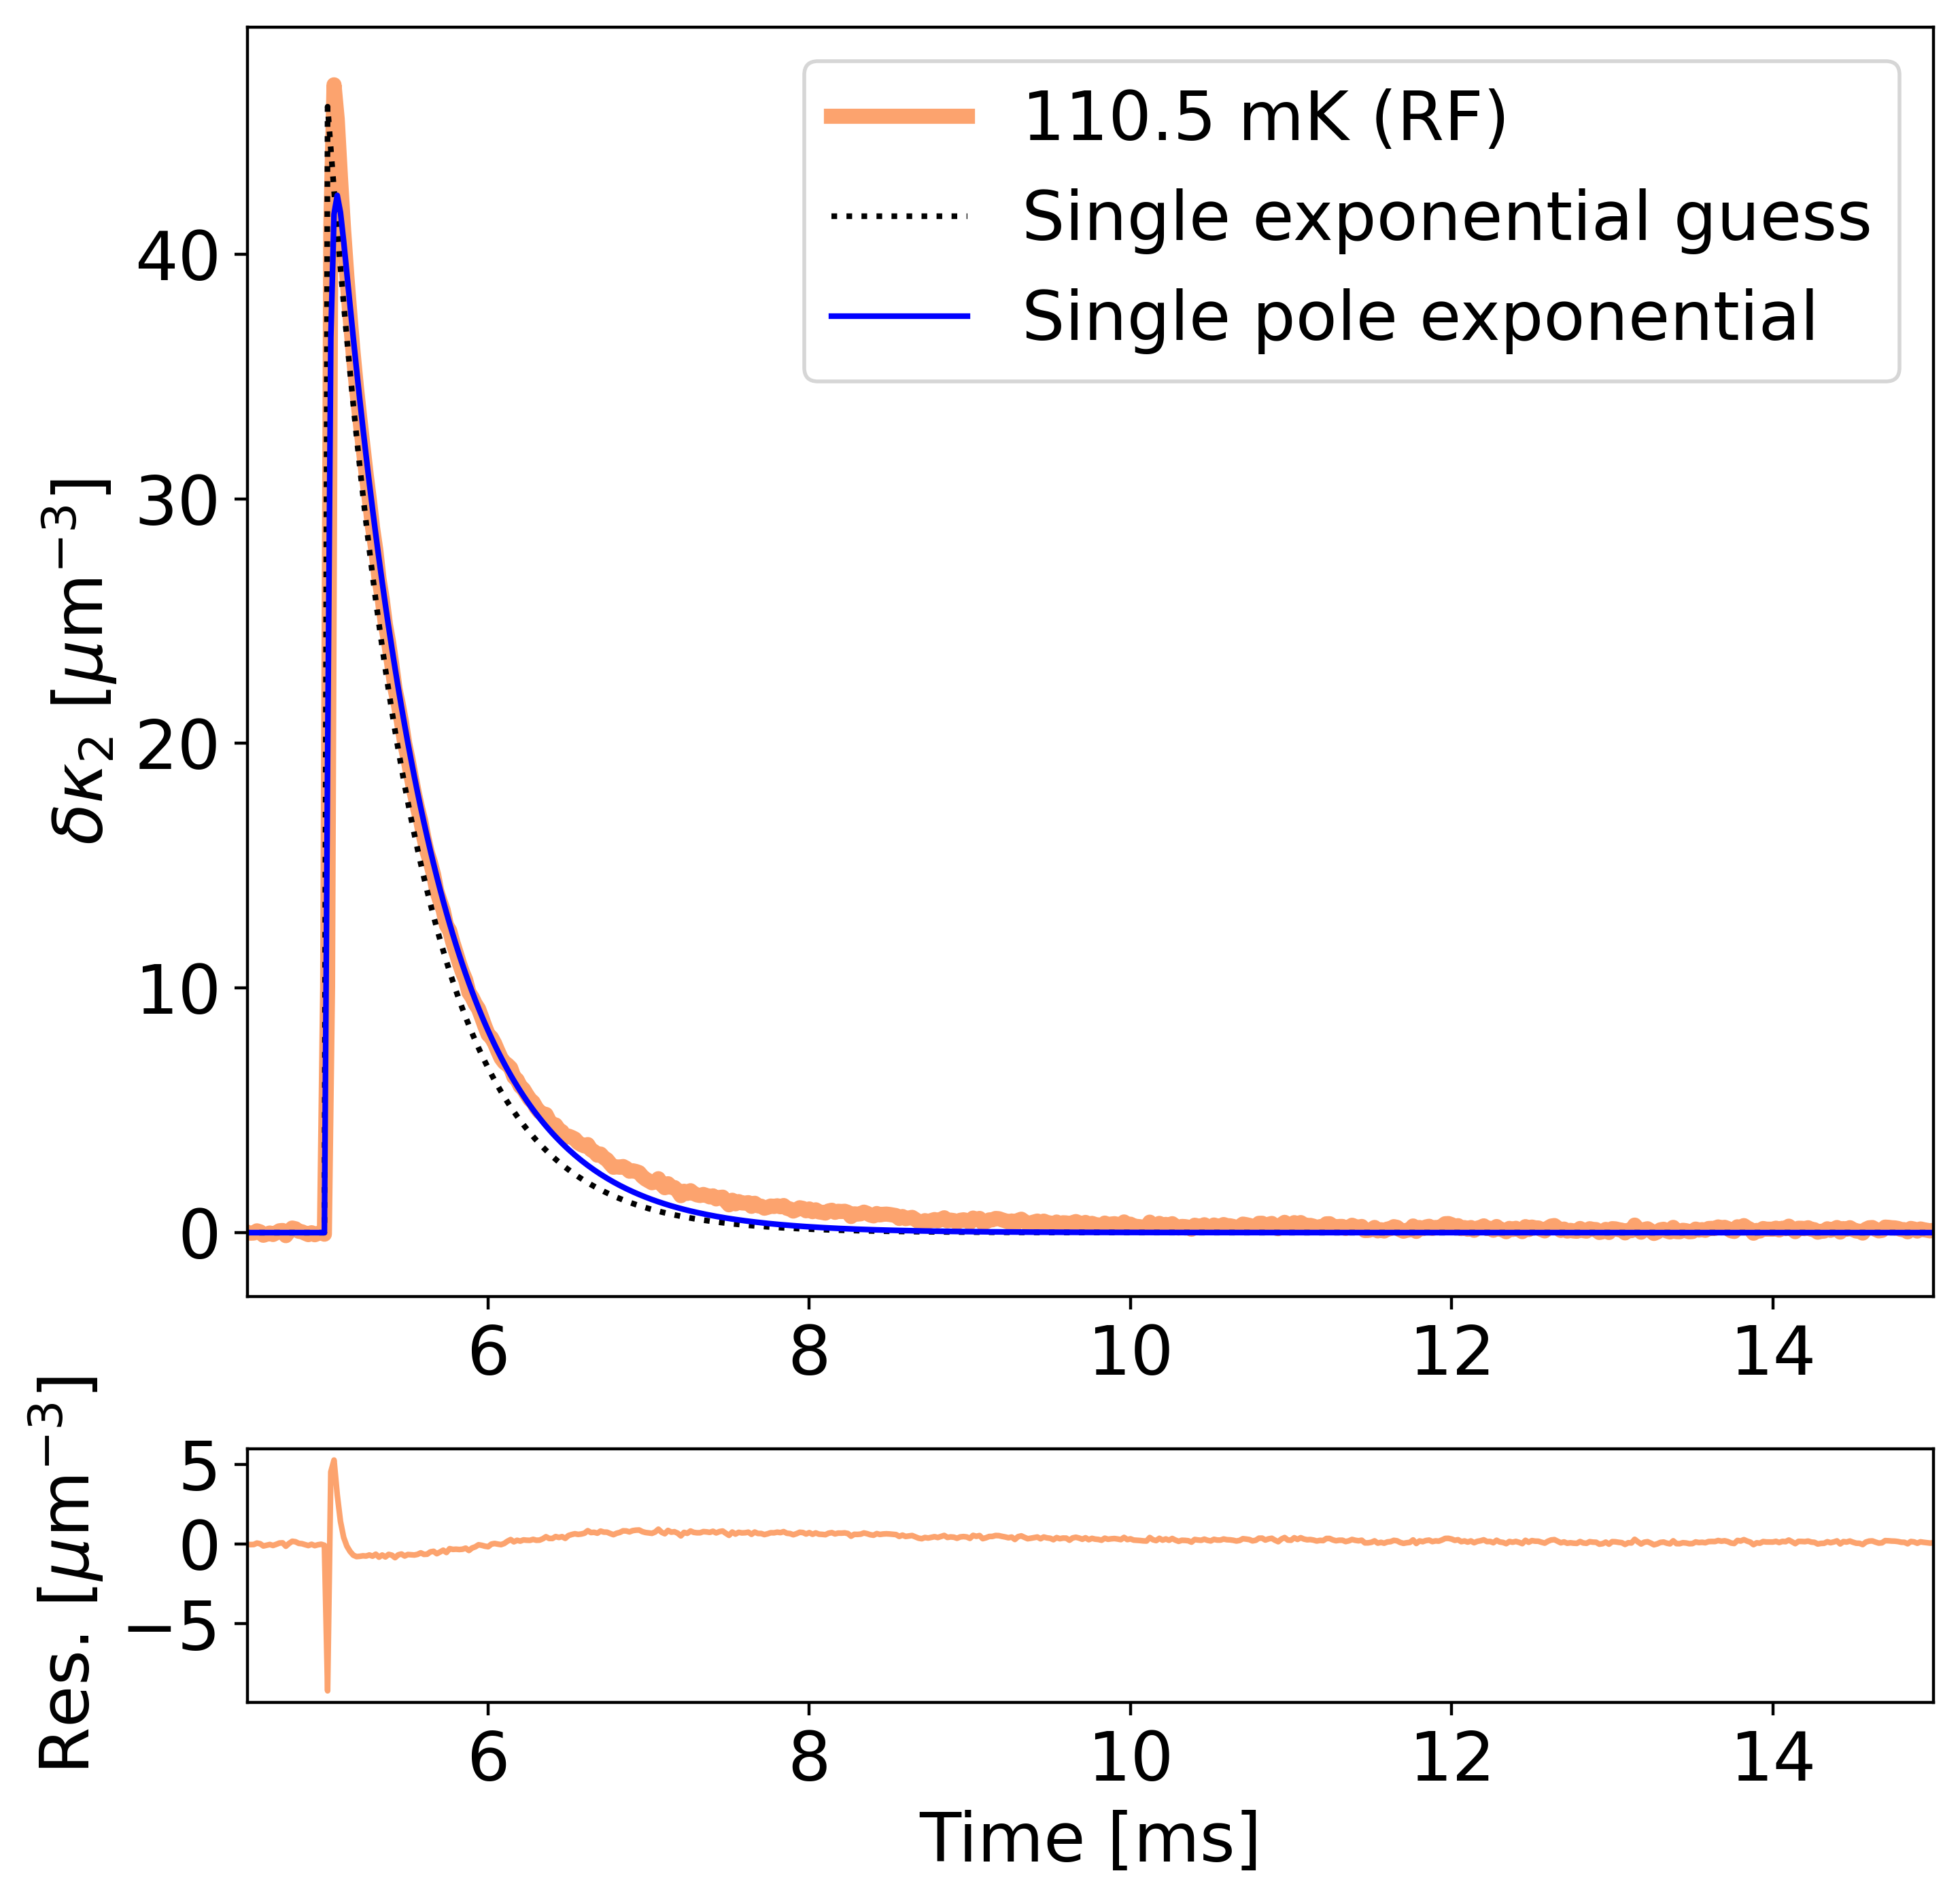

In [24]:
## Fit out to time
t_max_ms = 15.0

## Pulse plot limits
xlims    = [4.5, t_max_ms]

## Pick the temperature point
k = 125.0

## Get the color for this temperature
color = kipd.get_color( k , np.max(T_sp_mK), scale_min=0.0, offset=50.0)

## Open the data group for the LED voltage of interest
datafile = h5py.File(filepath, 'r')
data = datafile[f"{V_led:.1f}V"]

## Pull the averate pulse and time values
t_vals = np.array(data[f"{k:.1f}mK/time(ms)"])
p_vals = np.array(data[f"{k:.1f}mK/kappa2"])
if peak_normalize:
    p_vals = p_vals / np.max(p_vals)

#### === ==================== === ###

## Estimate the single exponential parameters
param_est = kipd.estimate_params(t_vals, p_vals, t_cutoff_ms=t_max_ms, verbose=True)
p_names   = ( "Amp", "Tau", "Kappa")
p_guess   = ( 50.0, param_est["tau"], 0.01)

## Try to fit to an exponential with a single fall time
popt_se, pcov_se = curve_fit( kipd.double_exp, t_vals[t_vals<t_max_ms], p_vals[t_vals<t_max_ms], p0=p_guess) 
print(pcov_se)
perr_se = np.sqrt(np.diag(pcov_se))

for i in np.arange(len(popt_se)):
    print(p_names[i], ":", popt_se[i], "+/-", perr_se[i])

## Get a curve for the best guess
all_guess = kipd.double_exp(t_vals,*p_guess)

## Get a curve for the optimal shape
all_pls = kipd.double_exp(t_vals,*popt_se)

#### === ==================== === ###

temp_label = ('%.1f mK (MC)' % k) if not show_mapped_T else ('%.1f mK (RF)' % T_rf_mK[np.argmin(np.abs(T_sp_mK-k))] )

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8,8), height_ratios=(1,0.2), dpi=400)

ax2.set_xlabel("Time [ms]")
ax2.set_ylabel(r"Res. $[\mu$m$^{-3}]$")
ax1.set_ylabel(r"$\delta \kappa_2 ~[\mu$m$^{-3}]$")

## Plot the pulse
ax1.plot( t_vals, p_vals, label=temp_label, color=color, linewidth=4)
ylims = ax1.get_ylim()

## Draw the single exponential guess
if True:
    ax1.plot( t_vals, kipd.single_exp(t_vals,param_est["amp"],param_est["tau"]), 'k:', label='Single exponential guess')

## Draw the overall shape and the prompt and delayed components' individual shapes
if popt_se is not None:
    ax1.plot( t_vals, all_pls  , 'b-', label="Single pole exponential")# - optimal")
    ax2.plot( t_vals, (p_vals-all_pls)/1., color=color )

## Finalize the axes
# ax1.set_ylim(ylims)
ax1.set_xlim(xlims if float(k)<201.0 else [xlims[0],7.5])#10.0])
ax2.set_xlim(xlims if float(k)<201.0 else [xlims[0],7.5])#10.0])
ax1.legend()

datafile.close()

# Example Fit: Emperical Model

/tmp/ipykernel_26278/3420416234.py:18: DeprecationWarning: `product` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `prod` instead.
  t_vals = np.array(data[f"{k:.1f}mK/time(ms)"])
/tmp/ipykernel_26278/3420416234.py:19: DeprecationWarning: `product` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `prod` instead.
  p_vals = np.array(data[f"{k:.1f}mK/kappa2"])


-- Parameter guess for single exponential -- 
     Decay time constant:  1.1399999999999997 ms
     Amplitude at t=0:     2558.742100169626
delay_a : 5.142512844284229 +/- 0.11372881395708355
delay_t (fall) : 4.9345786038882045 +/- 0.08003911387233081
delay_k (rise) : 0.3789461291013349 +/- 0.03435676175990826
prompt_a : 34.59125701848043 +/- 0.21320429351528544
prompt_t (fall) : 0.808713135815793 +/- 0.0066087076619356045
prompt_k (rise) : 0.024557932151498513 +/- 0.0004147876764506753


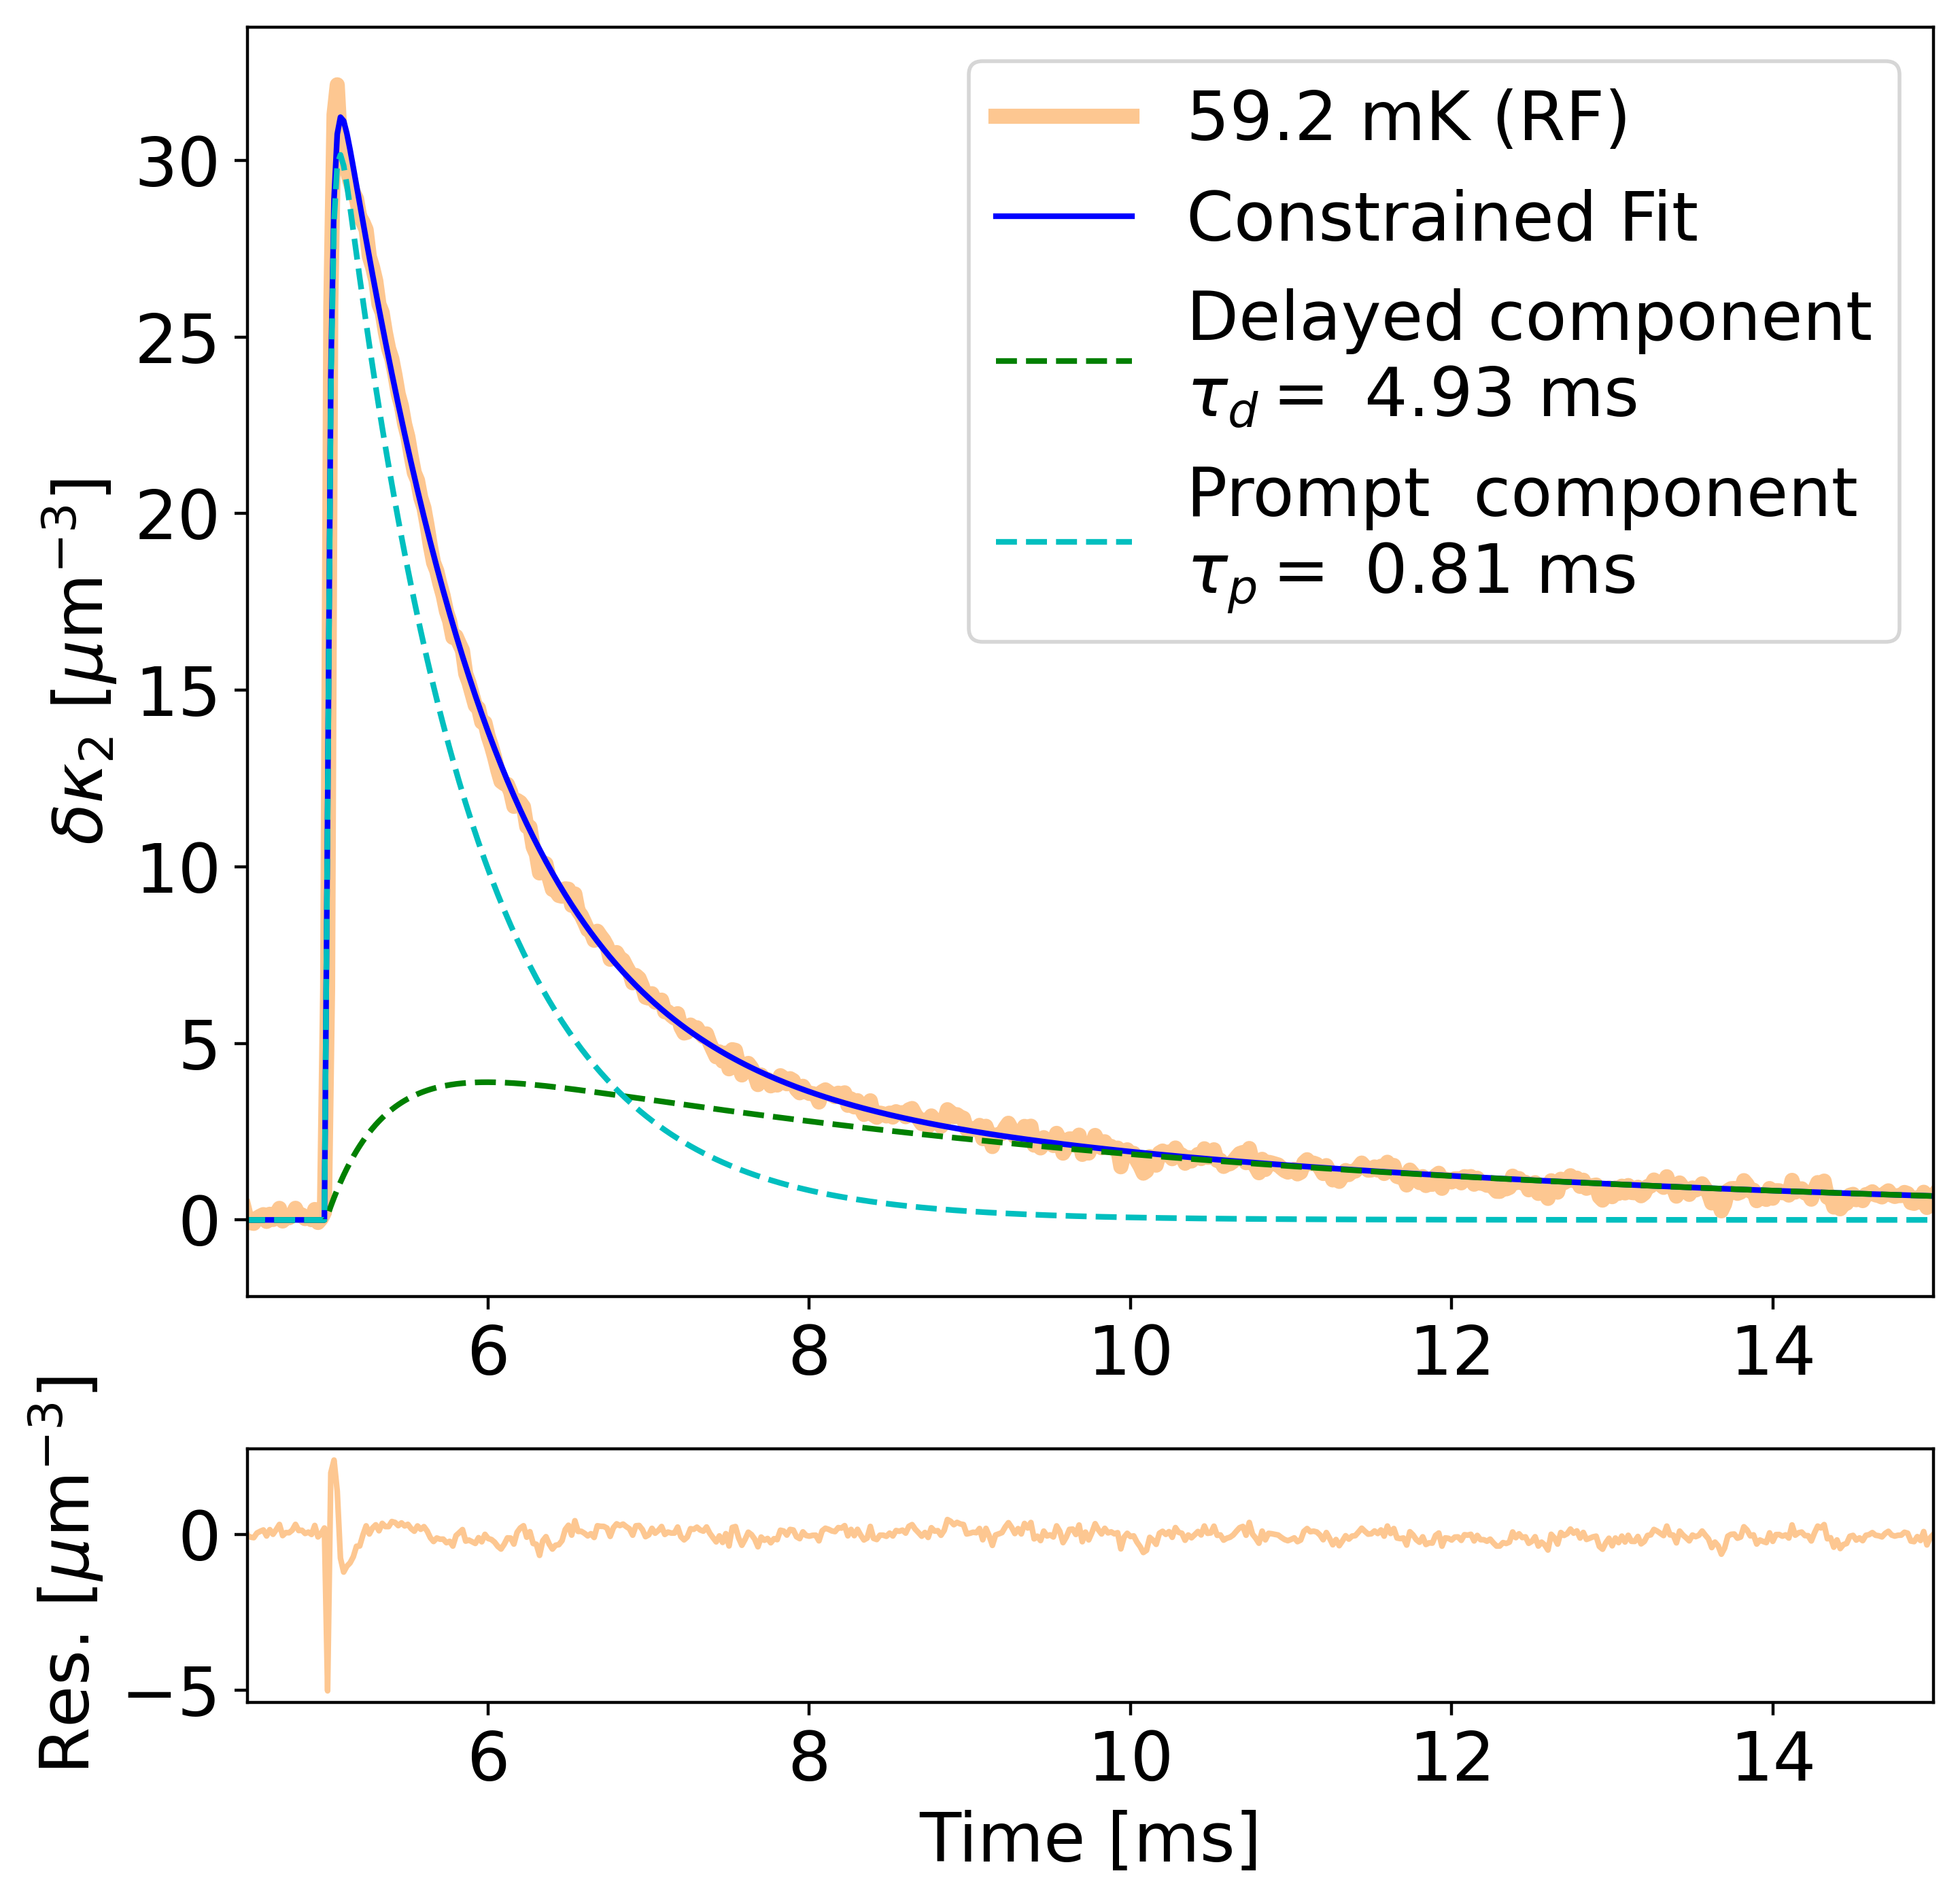

In [25]:
## Fit out to time
t_max_ms = 15.0

## Pulse plot limits
xlims    = [4.5, t_max_ms]

## Pick the temperature point
k = 75.0

## Get the color and temperature label for this temperature
color = kipd.get_color( k , np.max(T_sp_mK), scale_min=0.0, offset=50.0)
temp_label = ('%.1f mK (MC)' % k) if not show_mapped_T else ('%.1f mK (RF)' % T_rf_mK[np.argmin(np.abs(T_sp_mK-k))] )

## Open the data group for the LED voltage of interest
datafile = h5py.File(filepath, 'r')
data = datafile[f"{V_led:.1f}V"]

## Pull the averate pulse and time values
t_vals = np.array(data[f"{k:.1f}mK/time(ms)"])
p_vals = np.array(data[f"{k:.1f}mK/kappa2"])
if peak_normalize:
    p_vals = p_vals / np.max(p_vals)

#### === ==================== === ###

## Estimate the single exponential parameters
param_est = kipd.estimate_params(t_vals, p_vals, t_cutoff_ms=t_max_ms, verbose=True)

## Run the fit routine

## Extract the values from parameter estimation
tp_guess = param_est["tau"]
t_max    = param_est["tmax"]
p_max    = param_est["pmax"]

## Define parameter guesses for the prompt component
prompt_t = tp_guess
prompt_k = 0.01
prompt_a = p_max * np.exp((t_max-t0)/prompt_t) / (1-np.exp(-(t_max-t0)/prompt_k))
    
## Define parameter guesses for the delayed component
delay_t = 4.0*tp_guess
delay_k = 0.1
delay_a = prompt_a/1.0

## Prepare to plot the prompt guess
param_guess = [ delay_a, delay_t, delay_k, prompt_a, prompt_t, prompt_k]

## Fit the overall shape
p_opt, p_cov = curve_fit(kipd.double_pulse_shape,t_vals,p_vals,p0=param_guess,bounds=
                         (  (0,0,0,0,0,0) , ## lower
                            (np.inf,np.inf,np.inf,np.inf,np.inf,np.inf) ) ## upper
                         )

p_names = [ "delay_a"  , "delay_t (fall)"  , "delay_k (rise)" , 
            "prompt_a" , "prompt_t (fall)" , "prompt_k (rise)"]

p_err = np.sqrt(np.diag(p_cov))

for i in np.arange(len(p_opt)):
    print(p_names[i], ":", p_opt[i], "+/-", p_err[i])

## Get a curve for the best guess
all_guess = kipd.double_pulse_shape(t_vals,*param_guess)

## Get a curve for the optimal shape
all_pls = kipd.double_pulse_shape(t_vals,*p_opt)

## Get curves for the two components
fit_delay  = kipd.double_exp(t_vals,p_opt[0],p_opt[1],p_opt[2])
fit_prompt = kipd.double_exp(t_vals,p_opt[3],p_opt[4],p_opt[5])

#### === ==================== === ###

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8,8), height_ratios=(1,0.2), dpi=400)

ax2.set_xlabel("Time [ms]")
ax2.set_ylabel(r"Res. $[\mu$m$^{-3}]$")
ax1.set_ylabel(r"$\delta \kappa_2 ~[\mu$m$^{-3}]$")

## Plot the pulse
ax1.plot( t_vals, p_vals, label=temp_label, color=color, linewidth=4)
ylims = ax1.get_ylim()

## Draw the overall shape and the prompt and delayed components' individual shapes
if p_opt is not None:
    ax1.plot( t_vals, all_pls  , 'b-', label="Constrained Fit")# - optimal")
    ax1.plot( t_vals, fit_delay , 'g--', label="Delayed component\n"+r"$\tau_d=$ %.2f ms" % p_opt[1])
    ax1.plot( t_vals, fit_prompt, 'c--', label="Prompt  component\n"+r"$\tau_p=$ %.2f ms" % p_opt[4])
    ax2.plot( t_vals, (p_vals-all_pls)/1., color=color )

## Finalize the axes
# ax1.set_ylim(ylims)
ax1.set_xlim(xlims if float(k)<201.0 else [xlims[0],7.5])#10.0])
ax2.set_xlim(xlims if float(k)<201.0 else [xlims[0],7.5])#10.0])
ax1.legend()

datafile.close()

# Example Fit: Nonlinear ODE Pulse Shape

/tmp/ipykernel_26278/3621988666.py:19: DeprecationWarning: `product` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `prod` instead.
  t_vals = np.array(data[f"{k:.1f}mK/time(ms)"])
/tmp/ipykernel_26278/3621988666.py:20: DeprecationWarning: `product` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `prod` instead.
  p_vals = np.array(data[f"{k:.1f}mK/kappa2"])


-- Parameter guess for single exponential -- 
     Decay time constant:  1.38 ms
     Amplitude at t=0:     763.3995144912078
Amp : 672722765.0193703 +/- 474421417143642.06
Tau_qp : 4.833058027289281 +/- 0.125273582663807
n_qp0 : 60.21612334116852 +/- 19.90556197475904


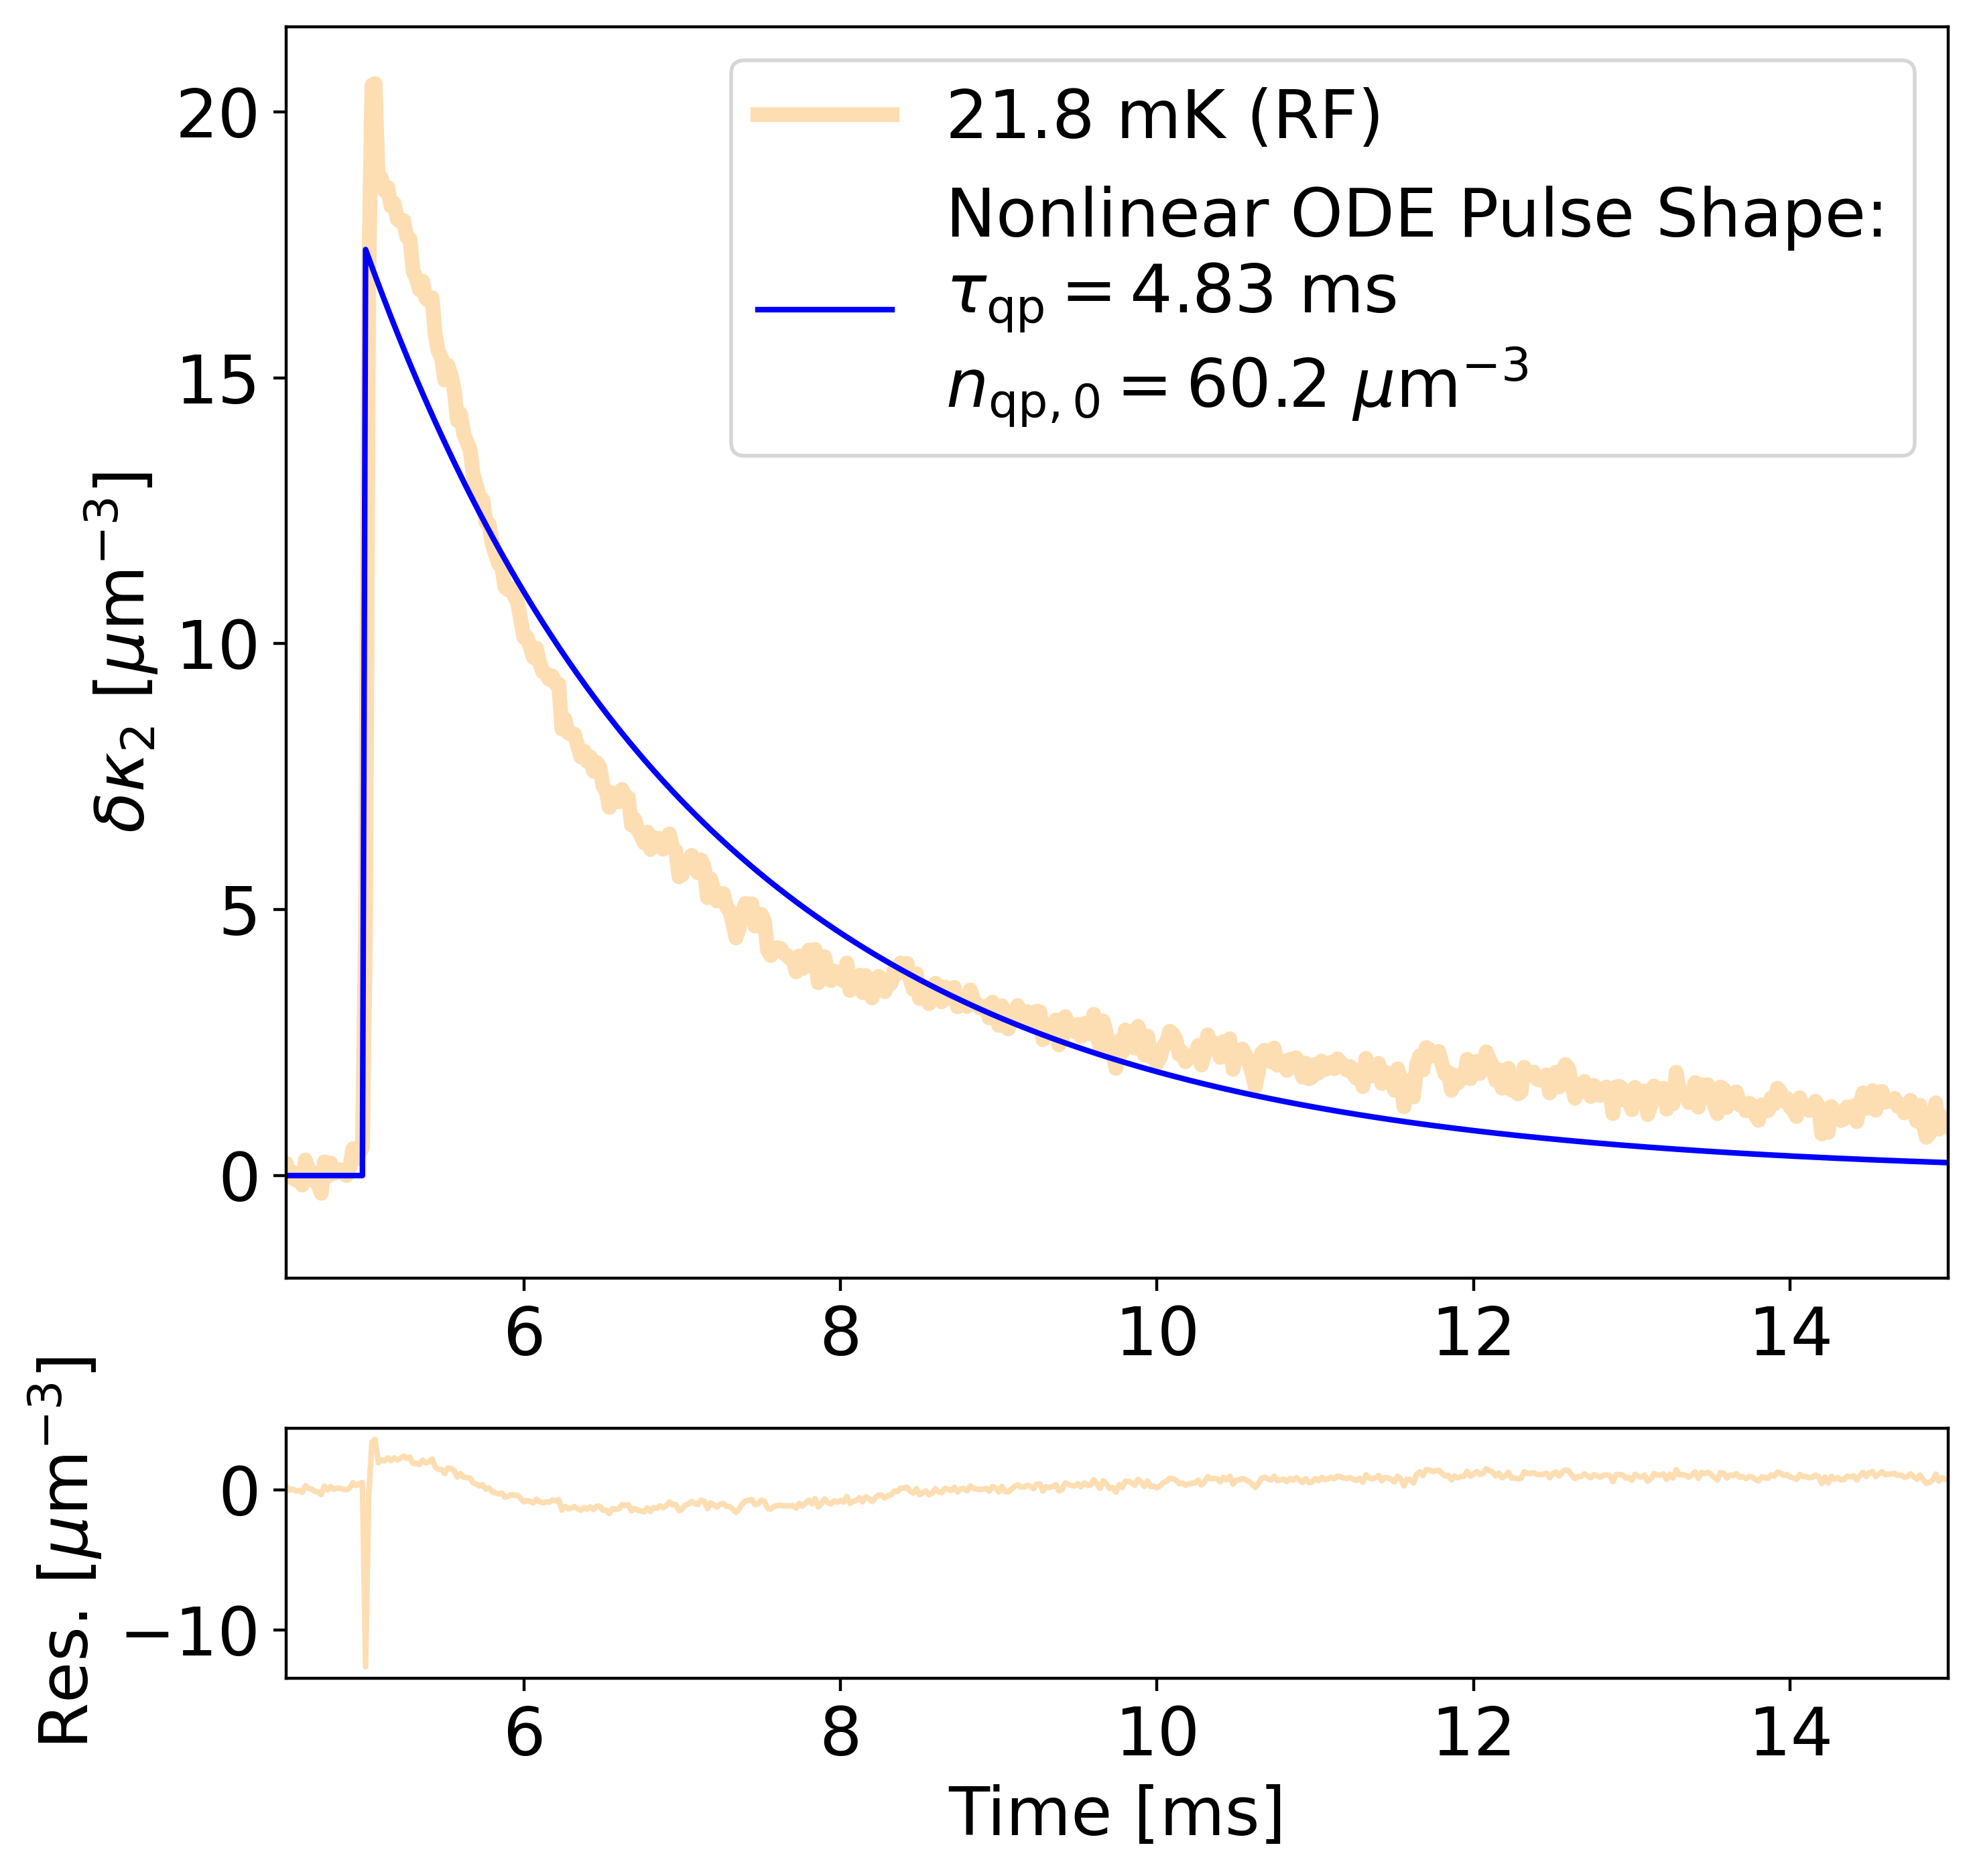

In [26]:
## Fit out to time
t_max_ms = 15.0

## Pulse plot limits
xlims    = [4.5, t_max_ms]

## Pick the temperature point
k = 25.0

## Get the color and temperature label for this temperature
color = kipd.get_color( k , np.max(T_sp_mK), scale_min=0.0, offset=50.0)
temp_label = ('%.1f mK (MC)' % k) if not show_mapped_T else ('%.1f mK (RF)' % T_rf_mK[np.argmin(np.abs(T_sp_mK-k))] )

## Open the data group for the LED voltage of interest
datafile = h5py.File(filepath, 'r')
data = datafile[f"{V_led:.1f}V"]

## Pull the averate pulse and time values
t_vals = np.array(data[f"{k:.1f}mK/time(ms)"])
p_vals = np.array(data[f"{k:.1f}mK/kappa2"])
if peak_normalize:
    p_vals = p_vals / np.max(p_vals)

#### === ==================== === ###

## Estimate the single exponential parameters
param_est = kipd.estimate_params(t_vals, p_vals, t_cutoff_ms=t_max_ms, verbose=True)
p_names   = ( "Amp", "Tau_qp", "n_qp0")
p_guess   = ( np.max(p_vals), param_est["tau"], 18.5)

## Try to fit to the nonlinear ODE pulse shape
popt_ode, pcov_ode = curve_fit( kipd.Nonlinear_pulse_shape, t_vals[t_vals<t_max_ms], p_vals[t_vals<t_max_ms], p0=p_guess) 
perr_ode = np.sqrt(np.diag(pcov_ode))

for i in np.arange(len(popt_ode)):
    print(p_names[i], ":", popt_ode[i], "+/-", perr_ode[i])

## Get a curve for the best guess
all_guess = kipd.Nonlinear_pulse_shape(t_vals,*p_guess)

## Get a curve for the optimal shape
all_pls = kipd.Nonlinear_pulse_shape(t_vals,*popt_ode)

#### === ==================== === ###

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8,8), height_ratios=(1,0.2), dpi=400)

ax2.set_xlabel("Time [ms]")
ax2.set_ylabel(r"Res. $[\mu$m$^{-3}]$")
ax1.set_ylabel(r"$\delta \kappa_2 ~[\mu$m$^{-3}]$")

## Plot the pulse
ax1.plot( t_vals, p_vals, label=temp_label, color=color, linewidth=4)
ylims = ax1.get_ylim()

## Draw the overall shape and the prompt and delayed components' individual shapes
ax1.plot( t_vals, all_pls  , 'b-', label="Nonlinear ODE Pulse Shape:\n"+r"$\tau_\mathrm{qp}=%.2f$ ms"%popt_ode[1]+"\n"+r"$n_\mathrm{qp,0}=%.1f~\mu\mathrm{m}^{-3}$" % popt_ode[2])# - optimal")
ax2.plot( t_vals, (p_vals-all_pls)/1., color=color )

## Finalize the axes
# ax1.set_ylim(ylims)
ax1.set_xlim(xlims if float(k)<201.0 else [xlims[0],7.5])#10.0])
ax2.set_xlim(xlims if float(k)<201.0 else [xlims[0],7.5])#10.0])
ax1.legend()

datafile.close()